In [1]:
import pandas as pd

# 创建一个简单的 DataFrame
data = {'Name': ['Google', 'Runoob', 'Taobao'], 'Age': [25, 30, 35]}
df = pd.DataFrame(data)

# 查看 DataFrame
print(df)

     Name  Age
0  Google   25
1  Runoob   30
2  Taobao   35


In [2]:
import pandas as pd

# Step 1: Load your Excel file (replace with CSV if needed)
df = pd.read_excel("black_futures.csv")

# Step 2: Rename columns for clarity
df.columns = ['row', 'date', 'asset', 'open', 'close']

# Step 3: Keep only useful columns
df = df[['date', 'asset', 'close']]

# Step 4: Pivot table to wide format (one column per asset)
df_wide = df.pivot(index='date', columns='asset', values='close')

# Step 5: Rename columns if needed
df_wide.columns.name = None
df_wide = df_wide.rename(columns={
    'RB00.SHF': 'RB',
    'J00.DCE': 'J',
    'I00.DCE': 'I',
    'HC00.SHF': 'HC'
})

# Step 6: Drop missing values
df_clean = df_wide.dropna()

# Optional: Save cleaned wide format
df_clean.to_csv("futures_clean.csv")
df_clean.to_csv("C:/Users/chris/Downloads/futures_clean.csv")

print(df_clean.head())


FileNotFoundError: [Errno 2] No such file or directory: 'black_futures.csv'

In [3]:
import os
os.getcwd()

'C:\\Users\\chris\\Desktop\\Jupyter Notebook Files'

In [5]:
import pandas as pd

# Step 1: Load your Excel file (replace with CSV if needed)
df = pd.read_csv("black_futures.csv")

# Step 2: Rename columns for clarity
df.columns = ['row', 'date', 'asset', 'open', 'close']

# Step 3: Keep only useful columns
df = df[['date', 'asset', 'close']]

# Step 4: Pivot table to wide format (one column per asset)
df_wide = df.pivot(index='date', columns='asset', values='close')

# Step 5: Rename columns if needed
df_wide.columns.name = None
df_wide = df_wide.rename(columns={
    'RB00.SHF': 'RB',
    'J00.DCE': 'J',
    'I00.DCE': 'I',
    'HC00.SHF': 'HC'
})

# Step 6: Drop missing values
df_clean = df_wide.dropna()

# Optional: Save cleaned wide format
df_clean.to_csv("futures_clean.csv")

print(df_clean.head())

ValueError: Length mismatch: Expected axis has 6 elements, new values have 5 elements

In [6]:
import pandas as pd
df = pd.read_csv("black_futures.csv")

print(df.columns)


Index(['number', 'time', 'thscode', 'open', 'close', 'Unnamed: 5'], dtype='object')


In [7]:
import pandas as pd

# Load CSV and drop the hidden "Unnamed" column(s)
df = pd.read_csv("black_futures.csv")
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Rename the columns we care about
df.columns = ['row', 'date', 'asset', 'open', 'close']

# Keep only useful columns
df = df[['date', 'asset', 'close']]

# Pivot to wide format
df_wide = df.pivot(index='date', columns='asset', values='close')
df_wide.columns.name = None

# Optional: Rename asset codes
df_wide = df_wide.rename(columns={
    'RB00.SHF': 'RB',
    'J00.DCE': 'J',
    'I00.DCE': 'I',
    'HC00.SHF': 'HC'
})

# Drop rows with missing values
df_clean = df_wide.dropna()

# Save cleaned version
df_clean.to_csv("futures_clean.csv")

print(df_clean.head())


Empty DataFrame
Columns: [nan, HC, I, J, RB]
Index: []


In [8]:
import pandas as pd

# ✅ Step 1: Load Excel file and parse dates correctly
df = pd.read_excel("black_futures.xlsx", parse_dates=['time'])

# ✅ Step 2: Drop any unnamed (empty) columns
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# ✅ Step 3: Rename columns for clarity
df.columns = ['row', 'date', 'asset', 'open', 'close']

# ✅ Step 4: Keep only the useful columns
df = df[['date', 'asset', 'close']]

# ✅ Step 5: Filter out unexpected asset codes (prevent pivot issues)
valid_assets = ['RB00.SHF', 'J00.DCE', 'I00.DCE', 'HC00.SHF']
df = df[df['asset'].isin(valid_assets)]

# ✅ Step 6: Pivot the data to wide format
df_wide = df.pivot(index='date', columns='asset', values='close')
df_wide.columns.name = None

# ✅ Step 7: Rename assets to short names
df_wide = df_wide.rename(columns={
    'RB00.SHF': 'RB',
    'J00.DCE': 'J',
    'I00.DCE': 'I',
    'HC00.SHF': 'HC'
})

# ✅ Step 8: Drop rows with any missing values
df_clean = df_wide.dropna()

# ✅ Step 9: Save cleaned version
df_clean.to_csv("futures_clean.csv")

# ✅ Step 10: Show preview
print(df_clean.head())


                HC      I       J      RB
date                                     
2020-07-29  3893.0  876.5  2135.0  3840.0
2020-07-30  3921.0  872.0  2135.0  3789.0
2020-07-31  4000.0  893.0  2135.0  3660.0
2020-08-03  4000.0  900.0  2135.0  3780.0
2020-08-04  4030.0  900.0  2135.0  3750.0


In [86]:
import pandas as pd

# Load the cleaned Excel file
df = pd.read_excel("futures_clean.csv.xlsx", index_col=0, parse_dates=True)

from statsmodels.tsa.stattools import adfuller

def adf_test(series, title=''):
    print(f'ADF Test for {title}')
    result = adfuller(series, autolag='AIC')
    labels = ['ADF Statistic', 'p-value', '# Lags Used', '# Observations Used']
    out = pd.Series(result[0:4], index=labels)
    for key, val in result[4].items():
        out[f'Critical Value ({key})'] = val
    print(out)
    print('=> Stationary' if result[1] <= 0.05 else '=> Non-stationary')
    print('-'*60)

# Loop through each asset column and test for stationarity
for column in df.columns:
    adf_test(df[column], title=column)

ADF Test for HC
ADF Statistic             -1.173795
p-value                    0.684766
# Lags Used               16.000000
# Observations Used     1196.000000
Critical Value (1%)       -3.435829
Critical Value (5%)       -2.863960
Critical Value (10%)      -2.568058
dtype: float64
=> Non-stationary
------------------------------------------------------------
ADF Test for I
ADF Statistic             -2.110248
p-value                    0.240414
# Lags Used                3.000000
# Observations Used     1209.000000
Critical Value (1%)       -3.435770
Critical Value (5%)       -2.863934
Critical Value (10%)      -2.568044
dtype: float64
=> Non-stationary
------------------------------------------------------------
ADF Test for J
ADF Statistic             -1.703267
p-value                    0.429430
# Lags Used                1.000000
# Observations Used     1211.000000
Critical Value (1%)       -3.435761
Critical Value (5%)       -2.863930
Critical Value (10%)      -2.568042
dtype: flo

In [87]:
df_diff = df.diff().dropna()
for column in df_diff.columns:
    adf_test(df_diff[column], title=column + " (1st Difference)")

ADF Test for HC (1st Difference)
ADF Statistic          -9.095868e+00
p-value                 3.716574e-15
# Lags Used             1.500000e+01
# Observations Used     1.196000e+03
Critical Value (1%)    -3.435829e+00
Critical Value (5%)    -2.863960e+00
Critical Value (10%)   -2.568058e+00
dtype: float64
=> Stationary
------------------------------------------------------------
ADF Test for I (1st Difference)
ADF Statistic            -23.265123
p-value                    0.000000
# Lags Used                2.000000
# Observations Used     1209.000000
Critical Value (1%)       -3.435770
Critical Value (5%)       -2.863934
Critical Value (10%)      -2.568044
dtype: float64
=> Stationary
------------------------------------------------------------
ADF Test for J (1st Difference)
ADF Statistic            -38.665614
p-value                    0.000000
# Lags Used                0.000000
# Observations Used     1211.000000
Critical Value (1%)       -3.435761
Critical Value (5%)       -2.863

In [12]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen
import pandas as pd

# Step 1: Load your cleaned time-series data (daily closing prices for RB, J, I, HC)
df = pd.read_excel("futures_clean.csv.xlsx", index_col=0, parse_dates=True)

# Step 2: Select only the columns you want to test (in the right order)
df_coint = df[['RB', 'J', 'I', 'HC']]

# Step 3: Run the Johansen cointegration test
# det_order=0 means constant term; k_ar_diff=1 means 1 lag difference
johan_result = coint_johansen(df_coint, det_order=0, k_ar_diff=1)

# Step 4: Print the test results
print("Trace Statistics:")
print(johan_result.lr1)

print("\nCritical Values (90%, 95%, 99%):")
print(johan_result.cvt)

# Optional: Print the cointegrating vectors
print("\nCointegrating Vectors (beta):")
print(johan_result.evec)


Trace Statistics:
[89.16901409 38.54230265 14.00341501  3.98355728]

Critical Values (90%, 95%, 99%):
[[44.4929 47.8545 54.6815]
 [27.0669 29.7961 35.4628]
 [13.4294 15.4943 19.9349]
 [ 2.7055  3.8415  6.6349]]

Cointegrating Vectors (beta):
[[ 0.00718216 -0.0002743   0.00025787  0.00057682]
 [-0.0014702  -0.00223948 -0.00033296  0.00068389]
 [-0.00021838 -0.00295006 -0.0076166   0.00024843]
 [-0.00558634  0.00254686  0.00066878  0.00023062]]


In [23]:
import pandas as pd
from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.vecm import coint_johansen

# -------------------------------
# Step 1: Load Cleaned Excel File
# -------------------------------
# Replace with the correct path to your Excel file
df = pd.read_excel("futures_clean.csv.xlsx", index_col=0, parse_dates=True)

# --------------------------------------
# Step 2: Select relevant columns & drop NA
# --------------------------------------
df_coint = df[['RB', 'J', 'I', 'HC']].dropna()

# --------------------------------------
# Step 3: Use VAR model to select optimal lag length by AIC
# --------------------------------------
model = VAR(df_coint)
lag_results = model.select_order(maxlags=10)  # Try up to 10 lags

# Print AIC, BIC, FPE, and HQIC results
print("Lag Selection Summary (VAR model):")
print(lag_results.summary())

# Choose lag with minimum AIC
optimal_lag = lag_results.aic

# --------------------------------------
# Step 4: Run Johansen Cointegration Test
# --------------------------------------
# Johansen requires k_ar_diff = optimal_lag - 1
k_ar_diff = optimal_lag - 1

# det_order=0: Include intercept (constant term)
johan_result = coint_johansen(df_coint, det_order=0, k_ar_diff=k_ar_diff)

# --------------------------------------
# Step 5: Print Results
# --------------------------------------
print("\nTrace Statistics:")
print(johan_result.lr1)

print("\nCritical Values (90%, 95%, 99%):")
print(johan_result.cvt)

print("\nCointegrating Vectors (beta):")
print(johan_result.evec)


C:\ProgramData\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Lag Selection Summary (VAR model):
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        45.11       45.13   3.897e+19       45.12
1        31.93       32.02   7.385e+13       31.96
2       31.86*      32.01*  6.841e+13*      31.91*
3        31.86       32.08   6.862e+13       31.94
4        31.86       32.15   6.878e+13       31.97
5        31.87       32.22   6.925e+13       32.00
6        31.88       32.31   7.033e+13       32.04
7        31.87       32.36   6.909e+13       32.05
8        31.87       32.43   6.963e+13       32.08
9        31.88       32.51   7.016e+13       32.12
10       31.89       32.58   7.048e+13       32.15
--------------------------------------------------

Trace Statistics:
[89.16901409 38.54230265 14.00341501  3.98355728]

Critical Values (90%, 95%, 99%):
[[44.4929 47.8545 54.6815]
 [27.0669 29.7961 35.4628]
 [13.4294 15.4943 19.9349]
 [ 2.7055  3.841

In [78]:
import numpy as np

# Assume beta is the matrix of cointegrating vectors from Johansen test
beta = johan_result.evec  # shape: (num_assets, num_vectors)

# Extract first and second cointegrating vectors (columns)
beta_1_raw = beta[:, 0]
beta_2_raw = beta[:, 1]

# Scale both vectors by 1000
beta_1_scaled = np.round(beta_1_raw * 1000, 4)
beta_2_scaled = np.round(beta_2_raw * 1000, 4)

# Print results
print("Scaled Cointegrating Vector 1:")
print(beta_1_scaled)

print("\nScaled Cointegrating Vector 2:")
print(beta_2_scaled)


Scaled Cointegrating Vector 1:
[ 7.1822 -1.4702 -0.2184 -5.5863]

Scaled Cointegrating Vector 2:
[-0.2743 -2.2395 -2.9501  2.5469]


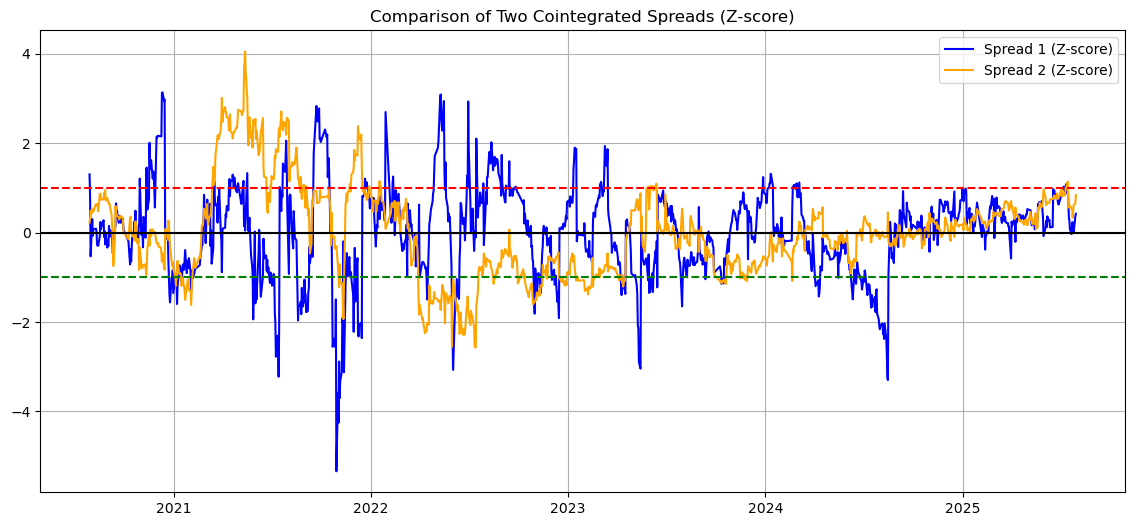

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Step 0: Load your futures-cleaned Excel data
df = pd.read_excel("futures_clean.csv.xlsx", index_col=0, parse_dates=True)

# Step 1: Select the aligned asset prices (make sure order matches beta vector)
df_coint = df[['RB', 'J', 'I', 'HC']].dropna()

# Step 2: Define your scaled beta vectors (from Johansen test output)
beta_1 = np.array([7.1822, -1.4702, -0.2184, -5.5863])
beta_2 = np.array([-0.2743, -2.2395, -2.9501, 2.5469])

# Step 3: Construct spreads
spread_1 = df_coint.values @ beta_1
spread_2 = df_coint.values @ beta_2

# Step 4: Turn into Series (with datetime index)
spread_1 = pd.Series(spread_1, index=df_coint.index)
spread_2 = pd.Series(spread_2, index=df_coint.index)

# Step 5: Compute Z-scores
z_1 = (spread_1 - spread_1.mean()) / spread_1.std()
z_2 = (spread_2 - spread_2.mean()) / spread_2.std()

# Step 6: Plot Z-scores
plt.figure(figsize=(14, 6))
plt.plot(z_1, label="Spread 1 (Z-score)", color='blue')
plt.plot(z_2, label="Spread 2 (Z-score)", color='orange')
plt.axhline(0, color='black')
plt.axhline(1, color='red', linestyle='--')
plt.axhline(-1, color='green', linestyle='--')
plt.title("Comparison of Two Cointegrated Spreads (Z-score)")
plt.legend()
plt.grid(True)
plt.show()


In [29]:
from statsmodels.tsa.stattools import adfuller
import numpy as np

# Already computed spreads (not z-scores)
# spread_1 and spread_2 are Series

# --- ADF TEST ---
def adf_pvalue(series):
    result = adfuller(series)
    return result[1]  # return p-value

# --- HALF-LIFE OF MEAN REVERSION ---
def half_life(series):
    spread_lag = series.shift(1).dropna()
    spread_diff = series.diff().dropna()
    spread_lag = spread_lag.loc[spread_diff.index]
    beta = np.polyfit(spread_lag, spread_diff, 1)[0]
    hl = -np.log(2) / beta
    return max(hl, 0)  # ensure non-negative

# --- HURST EXPONENT ---
def hurst_exponent(series, max_lag=100):
    lags = range(2, max_lag)
    tau = [np.std(np.subtract(series[lag:], series[:-lag])) for lag in lags]
    poly = np.polyfit(np.log(lags), np.log(tau), 1)
    return poly[0]  # Hurst exponent

# --- RUN METRICS ---
print("Spread 1:")
print("ADF p-value:", round(adf_pvalue(spread_1), 4))
print("Half-life:  ", round(half_life(spread_1), 2))
print("Hurst Exp:  ", round(hurst_exponent(spread_1), 4))

print("\nSpread 2:")
print("ADF p-value:", round(adf_pvalue(spread_2), 4))
print("Half-life:  ", round(half_life(spread_2), 2))
print("Hurst Exp:  ", round(hurst_exponent(spread_2), 4))


Spread 1:
ADF p-value: 0.0
Half-life:   5.47


C:\Users\chris\AppData\Local\Temp\ipykernel_32728\3735269556.py:25: RuntimeWarning: divide by zero encountered in log
  poly = np.polyfit(np.log(lags), np.log(tau), 1)


Hurst Exp:   nan

Spread 2:
ADF p-value: 0.0104
Half-life:   26.46
Hurst Exp:   nan


C:\Users\chris\AppData\Local\Temp\ipykernel_32728\3735269556.py:25: RuntimeWarning: divide by zero encountered in log
  poly = np.polyfit(np.log(lags), np.log(tau), 1)


🔍 Spread 1 Strategy Performance (Net of Costs)
Sharpe Ratio   : 1.4531
Max Drawdown   : 3974.6549
Total Return   : 45.6865
Win Rate       : 51.65%


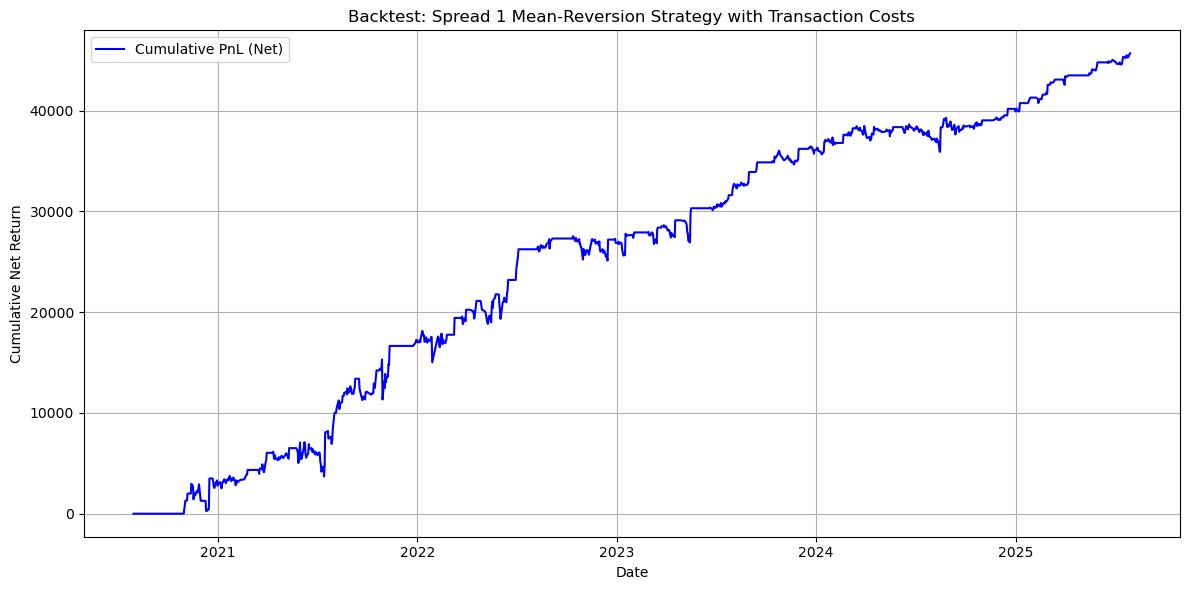

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === Step 0: Load data ===
df = pd.read_excel("futures_clean.csv.xlsx", index_col=0, parse_dates=True)
df_coint = df[['RB', 'J', 'I', 'HC']].dropna()

# === Step 1: Compute Spread 1 ===
beta_1 = np.array([7.1822, -1.4702, -0.2184, -5.5863])  # Scaled cointegration vector
spread_1 = df_coint.values @ beta_1
spread_1 = pd.Series(spread_1, index=df_coint.index)

# === Step 2: Compute Rolling Z-score ===
window = 60
rolling_mean = spread_1.rolling(window=window).mean()
rolling_std = spread_1.rolling(window=window).std()
z_score = (spread_1 - rolling_mean) / rolling_std

# === Step 3: Trading Logic ===
long_entry = z_score < -1
short_entry = z_score > 1
exit_signal = z_score * z_score.shift(1) < 0  # crosses zero

# === Step 4: Build Position Series ===
position = np.where(long_entry, 1, 0)
position = np.where(short_entry, -1, position)

# Carry forward position until exit
for i in range(1, len(position)):
    if position[i] == 0:
        position[i] = position[i - 1]
    if exit_signal.iloc[i]:
        position[i] = 0
position = pd.Series(position, index=spread_1.index)

# === Step 5: Compute Strategy Returns ===
spread_return = spread_1.diff().fillna(0)
strategy_returns = position.shift(1) * spread_return

# === Step 6: Add Transaction Costs ===
transaction_cost = 0.5 # e.g., 5 basis points per turnover
turnover = position.diff().abs()  # when position changes
costs = turnover * transaction_cost
strategy_returns_net = strategy_returns - costs  # Net of transaction costs

# === Step 7: Evaluate Performance (net of cost) ===
cumulative_pnl = strategy_returns_net.cumsum()
sharpe_ratio = strategy_returns_net.mean() / strategy_returns_net.std() * np.sqrt(252)
max_drawdown = (cumulative_pnl.cummax() - cumulative_pnl).max()
win_rate = (strategy_returns_net > 0).sum() / (strategy_returns_net != 0).sum()
total_return = cumulative_pnl.iloc[-1]/1000

# === Step 8: Display Results ===
print("🔍 Spread 1 Strategy Performance (Net of Costs)")
print(f"Sharpe Ratio   : {sharpe_ratio:.4f}")
print(f"Max Drawdown   : {max_drawdown:.4f}")
print(f"Total Return   : {total_return:.4f}")
print(f"Win Rate       : {win_rate:.2%}")

# === Step 9: Plot Cumulative PnL (Net of Costs) ===
plt.figure(figsize=(12, 6))
plt.plot(cumulative_pnl, label='Cumulative PnL (Net)', color='blue')
plt.title("Backtest: Spread 1 Mean-Reversion Strategy with Transaction Costs")
plt.xlabel("Date")
plt.ylabel("Cumulative Net Return")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


ADF p-value for Spread 1: 0.000000
ADF p-value for Spread 2: 0.042926


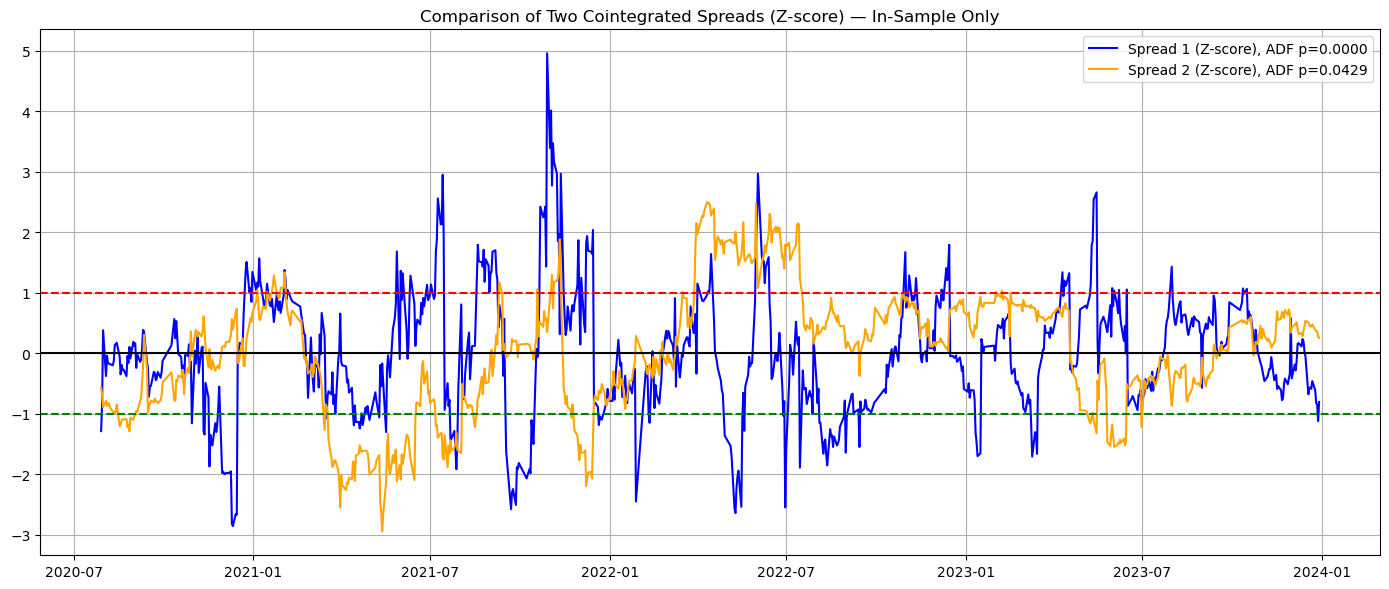

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# Step 0: Load your futures-cleaned Excel data
df = pd.read_excel("futures_clean.csv.xlsx", index_col=0, parse_dates=True)

# Step 1: Select aligned asset prices (RB, J, I, HC) and restrict to in-sample (first 833 rows)
df_coint = df[['HC', 'I', 'J', 'RB']].dropna()
df_coint_in_sample = df_coint.iloc[:833]

# Step 2: Define your newly scaled beta vectors
beta_1 = np.array([5.00051, 0.6142, 1.56603, -6.57481])
beta_2 = np.array([-2.29527, 2.7557, 2.12441, 0.75434])

# Step 3: Construct spreads
spread_1 = df_coint_in_sample.values @ beta_1
spread_2 = df_coint_in_sample.values @ beta_2

# Step 4: Turn into Series with correct datetime index
spread_1 = pd.Series(spread_1, index=df_coint_in_sample.index)
spread_2 = pd.Series(spread_2, index=df_coint_in_sample.index)

# Step 5: Compute Z-scores
z_1 = (spread_1 - spread_1.mean()) / spread_1.std()
z_2 = (spread_2 - spread_2.mean()) / spread_2.std()

# Step 6: ADF Test
adf_pval_1 = adfuller(spread_1)[1]
adf_pval_2 = adfuller(spread_2)[1]
print(f"ADF p-value for Spread 1: {adf_pval_1:.6f}")
print(f"ADF p-value for Spread 2: {adf_pval_2:.6f}")

# Step 7: Plot Z-scores
plt.figure(figsize=(14, 6))
plt.plot(z_1, label=f"Spread 1 (Z-score), ADF p={adf_pval_1:.4f}", color='blue')
plt.plot(z_2, label=f"Spread 2 (Z-score), ADF p={adf_pval_2:.4f}", color='orange')
plt.axhline(0, color='black')
plt.axhline(1, color='red', linestyle='--')
plt.axhline(-1, color='green', linestyle='--')
plt.title("Comparison of Two Cointegrated Spreads (Z-score) — In-Sample Only")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
